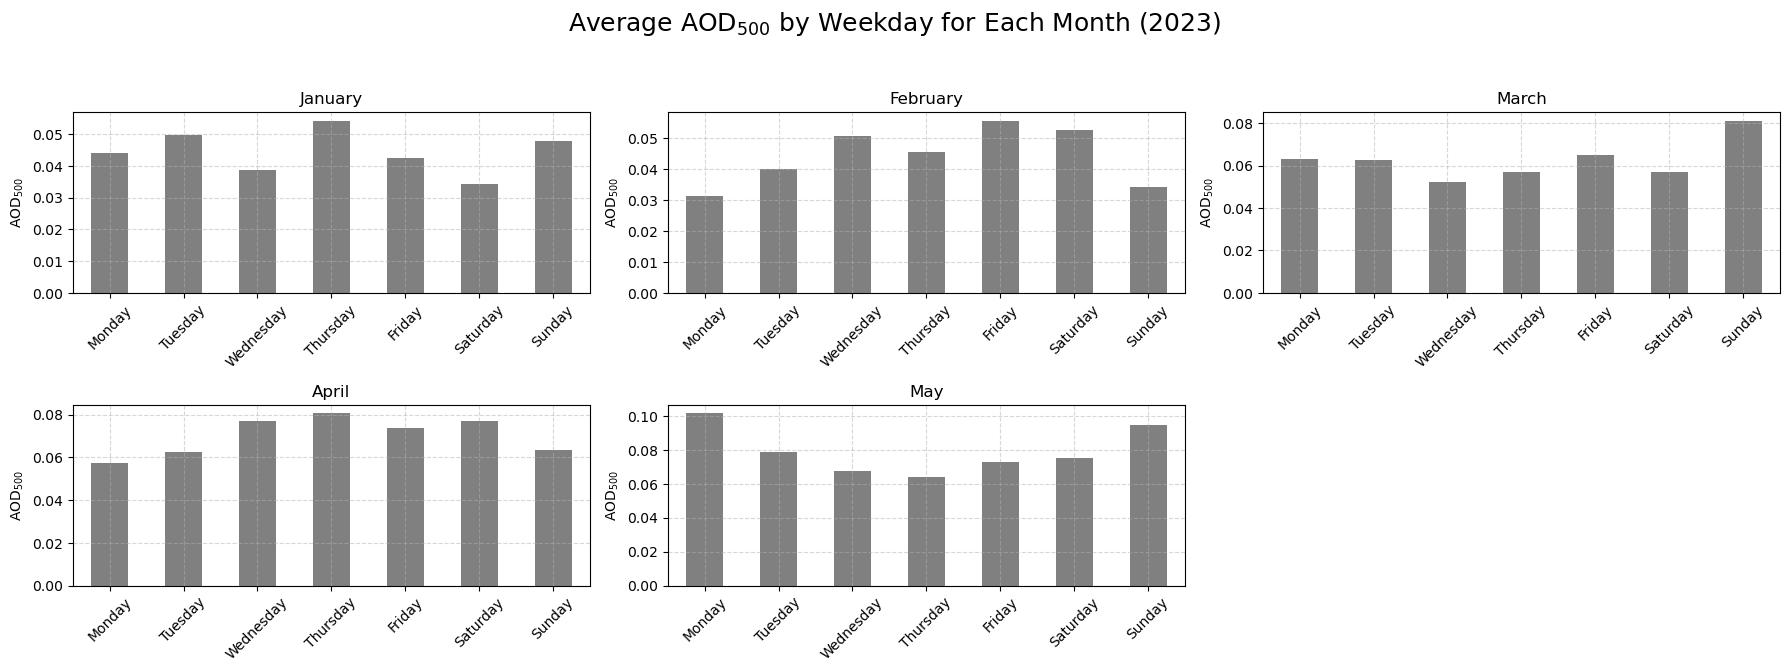

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load data
file_path = "20250101_20251231_Tucson.lev20"
df = pd.read_csv(file_path, delimiter=',', header=0, skiprows=6)

# Step 2: Parse datetime
df['Datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'],
                                format='%d:%m:%Y %H:%M:%S')

# Step 3: Replace invalid values
df.replace(-999.0, np.nan, inplace=True)

# Step 4: Add weekday and month columns
df['Weekday'] = df['Datetime'].dt.day_name()
df['Month'] = df['Datetime'].dt.month_name()
df['Month_Num'] = df['Datetime'].dt.month  # to keep correct month order

# Step 5: Define the weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Step 6: Prepare subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 12))  # 4 rows × 3 columns
fig.suptitle('Average AOD$_{500}$ by Weekday for Each Month (2023)', fontsize=18)

# Sort months correctly (January to December)
for i, (month_num, month_name) in enumerate(sorted(zip(df['Month_Num'].unique(), df['Month'].unique()))):
    ax = axes[i // 3, i % 3]  # Find subplot position
    month_data = df[df['Month_Num'] == month_num]
    
    weekly_avg = month_data.groupby('Weekday')['AOD_500nm'].mean().reindex(weekday_order)
    
    weekly_avg.plot(kind='bar', color='gray', ax=ax)
    ax.set_title(month_name)
    ax.set_ylabel("AOD$_{500}$")
    ax.set_xlabel("")
    ax.set_xticklabels(weekday_order, rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)

# Remove empty subplots if any (only if less than 12 months, usually not needed)
for j in range(i+1, 12):
    fig.delaxes(axes[j // 3, j % 3])

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for main title
plt.show()


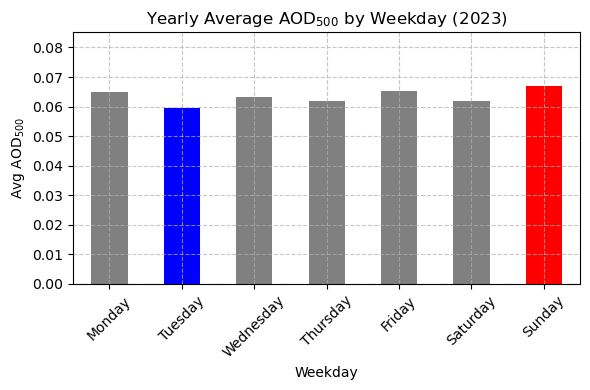

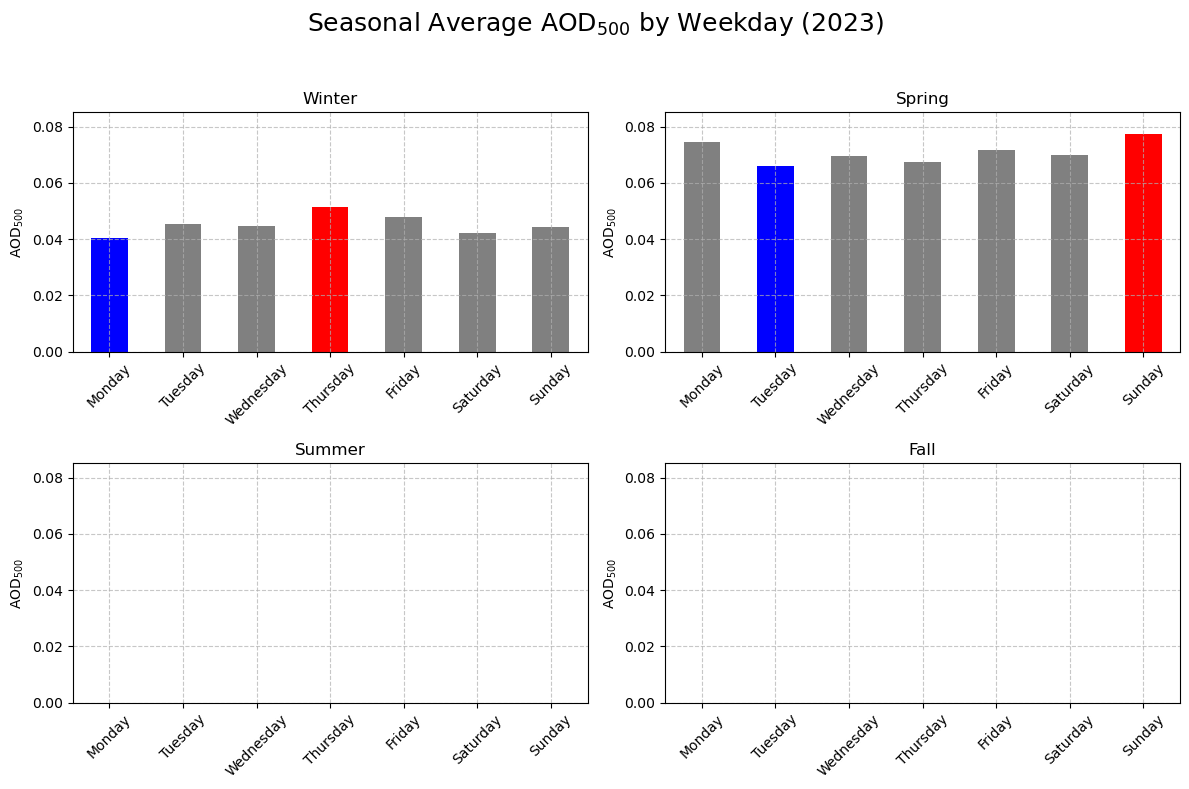

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load data
file_path = "20250101_20251231_Tucson.lev20"
df = pd.read_csv(file_path, delimiter=',', header=0, skiprows=6)

# Step 2: Parse datetime
df['Datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'],
                                format='%d:%m:%Y %H:%M:%S')

# Step 3: Replace invalid values
df.replace(-999.0, np.nan, inplace=True)

# Step 4: Add weekday and month columns
df['Weekday'] = df['Datetime'].dt.day_name()
df['Month'] = df['Datetime'].dt.month
df['Month_Name'] = df['Datetime'].dt.month_name()

# Step 5: Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

# Step 6: Define weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# ===== Calculate a global y-axis limit =====
global_max = 0
seasons = ['Winter', 'Spring', 'Summer', 'Fall']

for season in seasons:
    season_data = df[df['Season'] == season]
    seasonal_avg = season_data.groupby('Weekday')['AOD_500nm'].mean()
    if seasonal_avg.max() > global_max:
        global_max = seasonal_avg.max()

y_limit = global_max * 1.1

# ===== Yearly Average Plot =====
yearly_avg = df.groupby('Weekday')['AOD_500nm'].mean().reindex(weekday_order)

# Prepare colors: gray everywhere, red for max, blue for min
colors = ['gray'] * 7
if not yearly_avg.isnull().all():
    max_idx = yearly_avg.idxmax()
    min_idx = yearly_avg.idxmin()
    if max_idx in weekday_order:
        colors[weekday_order.index(max_idx)] = 'red'
    if min_idx in weekday_order:
        colors[weekday_order.index(min_idx)] = 'blue'

plt.figure(figsize=(6,4))
yearly_avg.plot(kind='bar', color=colors)
plt.ylim(0, y_limit)
plt.ylabel("Avg AOD$_{500}$")
plt.xlabel("Weekday")
plt.title("Yearly Average AOD$_{500}$ by Weekday (2023)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ===== Seasonal Average Plots =====
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Seasonal Average AOD$_{500}$ by Weekday (2023)', fontsize=18)

for i, season in enumerate(seasons):
    ax = axes[i // 2, i % 2]
    season_data = df[df['Season'] == season]
    seasonal_avg = season_data.groupby('Weekday')['AOD_500nm'].mean().reindex(weekday_order)
    
    # Prepare colors for each season separately
    season_colors = ['gray'] * 7
    if not seasonal_avg.isnull().all():
        max_idx = seasonal_avg.idxmax()
        min_idx = seasonal_avg.idxmin()
        if max_idx in weekday_order:
            season_colors[weekday_order.index(max_idx)] = 'red'
        if min_idx in weekday_order:
            season_colors[weekday_order.index(min_idx)] = 'blue'
    
    seasonal_avg.plot(kind='bar', color=season_colors, ax=ax)
    ax.set_ylim(0, y_limit)
    ax.set_title(season)
    ax.set_ylabel("AOD$_{500}$")
    ax.set_xlabel("")
    ax.set_xticklabels(weekday_order, rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
